# Tutorial 5: BEM and PTO Parameter Sensitivity for AquaHarmonics

This tutorial computes the **sensitivity of optimal electrical power** to both
**BEM (hydrodynamic) parameters** and **PTO (Power Take-Off) parameters** using
the unified sensitivity API in `wecopttool_differentiable`.

Unlike BEM parameters (which enter the dynamics residual only), PTO parameters
enter through **all three** components of the optimization problem:

1. **Dynamics residual** $r(x; p)$: PTO passive forces (spring, friction, inertia)
2. **Objective** $f(x; p)$: generator loss map (winding resistance, torque constant)
3. **Inequality constraints** $g(x; p)$: torque/speed/power limits

The full Fiacco post-optimality sensitivity formula is:

$$\frac{d\varphi^*}{dp}
= \frac{\partial f}{\partial p}
+ \lambda^\top \frac{\partial r}{\partial p}
+ \sum_i \mu_i^\top \frac{\partial g_i}{\partial p}$$

where $\lambda$ are the dynamics multipliers and $\mu_i$ are the inequality
constraint multipliers, both returned by IPOPT.

### Table of Contents

1. [Setup](#1.-Setup) -- device, PTO, forces, constraints
2. [Solve](#2.-Solve) -- IPOPT optimal control
3. [Define Parameters](#3.-Define-Parameters) -- BEM and PTO parameter pytrees
4. [Parametric Functions](#4.-Parametric-Functions) -- force and objective as functions of params
5. [BEM and PTO Sensitivity](#5.-BEM-and-PTO-Sensitivity)
6. [Joint BEM + PTO](#6.-Joint-BEM-+-PTO-Sensitivity) -- single call for both
6b. [Mooring stiffness](#6b.-Mooring-stiffness-sensitivity) -- parametric_forces for mooring
7. [Finite-Difference Validation](#7.-Finite-Difference-Validation)
8. [Visualize](#8.-Visualize)
9. [Summary](#9.-Summary)

## 1. Setup

Identical AquaHarmonics device as Tutorial 2.

In [19]:
import capytaine as cpy
from capytaine.io.meshio import load_from_meshio
from collections import namedtuple
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import wecopttool as wot
from wecopttool_differentiable import (
    WEC_IPOPT,
    sensitivity,
    extract_bem_params,
    make_joint_params,
    plot_sensitivity_bars,
    make_linear_mooring_parametric,
    make_pto_passive_parametric,
    make_electrical_power_obj_parametric,
    validate_sensitivity,
    fd_validate,
    fd_check_residual,
    fd_check_objective,
)

plt.style.use('tableau-colorblind10')
cc = plt.rcParams['axes.prop_cycle'].by_key()['color']

### Geometry and BEM

In [20]:
# Hull mesh
ah_hull = wot.geom.AquaHarmonics()
mesh = ah_hull.mesh(mesh_size_factor=0.25)

# Capytaine FloatingBody
mesh_obj = load_from_meshio(mesh, 'AquaHarmonics')
lid_mesh = mesh_obj.generate_lid(-5e-2)
fb = cpy.FloatingBody(mesh=mesh_obj, lid_mesh=lid_mesh, name="AquaHarmonics")
fb.add_translation_dof(name="Heave")
ndof = fb.nb_dofs

# Hydrostatics and mass
g = 9.81
rho = 1025
fb.center_of_mass = [0, 0, 0]
fb.rotation_center = fb.center_of_mass
displaced_mass = fb.compute_rigid_body_inertia(rho=rho).values
displacement = displaced_mass / rho
fb.mass = np.atleast_2d(5e3)

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

In [21]:
# Waves
amplitude = 0.5
wavefreq = 0.24 / 2
phase = 30
wavedir = 0
f1 = wavefreq
nfreq = 10

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

# BEM
freq = wot.frequency(f1, nfreq, False)
bem_data = wot.run_bem(fb, freq, rho=rho, g=g)

[23:04:46] WARNING  center_of_mass already defined as [0, 0, 0].

           WARNING  rotation_center already defined as [0, 0, 0].

           WARNING  FloatingBody has no inertia_matrix field. The FloatingBody mass is defined and will be used for
                    calculating the inertia matrix.

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

           WARNING  FloatingBody has no hydrostatic_stiffness field. Capytaine will auto-populate the hydrostatic  
                    stiffness based on the provided mesh.

The resolution of the mesh might be insufficient for omega ranging from 6.786 to 7.540.
This warning appears when the largest panel of this mesh has radius > wavelength/8.


           WARNING  Mesh resolution for 4 problems:                                                                
                    The resolution of the mesh might be insufficient for omega ranging from 6.786 to 7.540.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([dataset, diffraction_cases])
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([d

### PTO and drive train

In [22]:
# Drive train parameters
radii = {
    "S1": 0.02, "S2": 0.795, "S3": 0.1595, "S4": 0.200525, "S5": 0.40105,
    "S6": 0.12575, "S7": 0.103
}

inertias = {
    "Igen": 3.9, "I1": 0.029, "I2": 25.6, "I3": 1.43, "I4": 1.165, "I5": 4.99,
    "I6": 1.43, "I7": 1.5, "mps": 40
}

friction_dict = {
    "Bgen": 7, "Bdrivetrain": 40, "Bshaft": 40, "Bspring_pulley": 80,
    "Bpneumatic_spring": 700, "Bpneumatic_spring_static1": 0,
    "Bpspneumatic_spring_static2": 0
}

airspring = {
    "gamma": 1.4, "height": 1, "diameter": 3, "area": 0.0709676,
    "press_init": 854e3, "vol_init": 1
}

gear_ratios = {
    "R21": radii['S2'] / radii['S1'],
    "R45": radii['S4'] / radii['S5'],
    "R67": radii['S6'] / radii['S7'],
    "spring": radii['S6'] * (radii['S4'] / radii['S5'])
}

inertia_pto = (
    (inertias["Igen"] + inertias["I1"]) * gear_ratios['R21']**2 +
    (inertias['I2'] + inertias['I3'] + inertias['I4']) +
    gear_ratios["R45"]**2 * (
        inertias['I5'] + inertias['I6'] +
        inertias["I7"] * gear_ratios['R67']**2 +
        inertias['mps'] * radii['S6']**2
    )
)

friction_pto = (
    friction_dict['Bgen'] * gear_ratios['R21']**2 +
    friction_dict['Bdrivetrain'] +
    gear_ratios["R45"]**2 * (
        friction_dict["Bshaft"] +
        friction_dict["Bspring_pulley"] * gear_ratios['R67']**2 +
        friction_dict["Bpneumatic_spring"] * radii['S6']**2
    )
)

# Generator
winding_resistance = 0.4
torque_coefficient = 1.5

def power_loss(speed, torque):
    return winding_resistance * (torque / torque_coefficient)**2

# Generator limits
rot_max = 10000 * 2 * np.pi / 60
torque_max = 300
power_max = 80e3

In [23]:
# PTO object
name = ["PTO_Heave"]
gear_ratio_generator = gear_ratios['R21'] / radii['S3']
kinematics = gear_ratio_generator * np.eye(ndof)
controller = wot.controllers.unstructured_controller()
nstate_opt = 2 * nfreq
pto = wot.pto.PTO(ndof, kinematics, controller, None, power_loss, name)

### Forces and constraints

In [24]:
# Additional forces
def f_buoyancy(wec, x_wec, x_opt, wave, nsubsteps=1):
    return displacement * rho * g * jnp.ones([wec.ncomponents * nsubsteps, wec.ndof])

def f_gravity(wec, x_wec, x_opt, wave, nsubsteps=1):
    return -1 * wec.inertia_matrix.item() * g * jnp.ones([wec.ncomponents * nsubsteps, wec.ndof])

def f_pretension_wec(wec, x_wec, x_opt, wave, nsubsteps=1):
    return -1 * (f_buoyancy(wec, x_wec, x_opt, wave, nsubsteps)
                 + f_gravity(wec, x_wec, x_opt, wave, nsubsteps))

def f_pto_passive(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat, pos)
    acc = jnp.dot(wec.derivative_mat, vel)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    spring = -(gear_ratios['spring'] * airspring['gamma'] * airspring['area'] *
              airspring['press_init'] / airspring['vol_init']) * pos
    f_spring = jnp.dot(time_matrix, spring)
    fric = -(friction_pto +
             friction_dict['Bpneumatic_spring_static1'] *
             gear_ratios['spring']) * vel
    f_fric = jnp.dot(time_matrix, fric)
    inertia = inertia_pto * acc
    f_inertia = jnp.dot(time_matrix, inertia)
    return f_spring + f_fric + f_inertia

def f_pto_line(wec, x_wec, x_opt, wave, nsubsteps=1):
    f_pto_force = pto.force_on_wec(wec, x_wec, x_opt, wave, nsubsteps)
    f_pre = f_pretension_wec(wec, x_wec, x_opt, wave, nsubsteps)
    return f_pto_force + f_pre

# Linear mooring stiffness (additional force for sensitivity illustration)
K_mooring = 1e4  # N/m
def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    return jnp.dot(time_matrix, -K_mooring * pos)

f_add = {
    'PTO': f_pto_line,
    'PTO_passive': f_pto_passive,
    'mooring': f_mooring,
    'buoyancy': f_buoyancy,
    'gravity': f_gravity,
}

In [25]:
# Constraints
torque_peak_max = 280
rot_speed_max = 10000 * 2 * np.pi / 60
min_line_tension = -1000
nsubsteps = 2

def const_peak_torque_pto(wec, x_wec, x_opt, wave):
    torque = pto.force(wec, x_wec, x_opt, wave, nsubsteps)
    return torque_peak_max - jnp.abs(torque.flatten())

def const_speed_pto(wec, x_wec, x_opt, wave):
    rot_vel = pto.velocity(wec, x_wec, x_opt, wave, nsubsteps)
    return rot_speed_max - jnp.abs(rot_vel.flatten())

def const_power_pto(wec, x_wec, x_opt, wave):
    power_mech = (
        pto.velocity(wec, x_wec, x_opt, wave, nsubsteps) *
        pto.force(wec, x_wec, x_opt, wave, nsubsteps)
    )
    return power_max - jnp.abs(power_mech.flatten())

def constrain_min_tension(wec, x_wec, x_opt, wave):
    total_tension = -1 * f_pto_line(wec, x_wec, x_opt, wave, nsubsteps)
    return total_tension.flatten() + min_line_tension

def zero_mean_pos(wec, x_wec, x_opt, wave):
    return x_wec[0]

constraints = [
    {'type': 'ineq', 'fun': constrain_min_tension},
    {'type': 'ineq', 'fun': const_peak_torque_pto},
    {'type': 'ineq', 'fun': const_speed_pto},
    {'type': 'ineq', 'fun': const_power_pto},
    {'type': 'eq', 'fun': zero_mean_pos},
]

In [26]:
# Build WEC
wec = WEC_IPOPT.from_bem(
    bem_data, constraints=constraints, f_add=f_add,
)
obj_fun = pto.average_power
print(f"nstate_wec = {wec.nstate_wec}, nstate_opt = {nstate_opt}")

[23:05:03] WARNING  Linear damping for DOF "Heave" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

nstate_wec = 20, nstate_opt = 20


## 2. Solve

Solve the optimal control problem at the nominal PTO parameters.

In [27]:
scale_x_wec = 1e1
scale_x_opt = 50e-2
scale_obj = 1e-3

solve_kw = dict(
    x_wec_0=np.ones(wec.nstate_wec) * 1e-3,
    x_opt_0=np.ones(nstate_opt) * 1e-3,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
    optim_options={'max_iter': 2000, 'tol': 1e-8, 'print_level': 0},
)

res = wec.solve(waves, obj_fun, nstate_opt, **solve_kw)[0]
print(f"Optimal power: {res.fun/1e3:.2f} kW")
print(f"Success: {res.success}")

# Inspect available constraint multipliers
print(f"\nConstraint multipliers available:")
for name, mu in res.constraint_multipliers.items():
    print(f"  {name}: shape={mu.shape}, max|mu|={np.max(np.abs(mu)):.4e}")

Optimal power: -1.28 kW
Success: True

Constraint multipliers available:
  user_constraint_0: shape=(40,), max|mu|=2.3165e-03
  user_constraint_1: shape=(40,), max|mu|=3.4894e-10
  user_constraint_2: shape=(40,), max|mu|=5.5756e-10
  user_constraint_3: shape=(40,), max|mu|=3.5250e-08
  user_constraint_4: shape=(1,), max|mu|=1.8565e+02


## 3. Define Parameters

We define `BEMParams` (via `extract_bem_params`) and `PTOParams` containing
the parameters we want sensitivities for. These must be explicit pytrees
so JAX can differentiate through them.

In [28]:
PTOParams = namedtuple('PTOParams', [
    'friction_pto',      # total PTO friction [Nm s/rad]
    'inertia_pto',       # total PTO inertia [kg m^2]
    'spring_stiffness',  #  spring effective stiffness coefficient
    'winding_resistance', # generator winding resistance [Ohm]
    'torque_coefficient', # generator torque constant [Nm/A]
])

# Nominal values
pto_params_nominal = PTOParams(
    friction_pto=jnp.float64(friction_pto),
    inertia_pto=jnp.float64(inertia_pto),
    spring_stiffness=jnp.float64(
        gear_ratios['spring'] * airspring['gamma'] *
        airspring['area'] * airspring['press_init'] / airspring['vol_init']
    ),
    winding_resistance=jnp.float64(winding_resistance),
    torque_coefficient=jnp.float64(torque_coefficient),
)

# BEM parameters (from hydro data)
bem_params = extract_bem_params(wec._hydro_data)

# Mooring parameters (for sensitivity )
MooringParams = namedtuple('MooringParams', ['K'])
mooring_params_nominal = MooringParams(K=jnp.float64(K_mooring))

print("PTO parameters:")
for field in PTOParams._fields:
    print(f"  {field:25s} = {float(getattr(pto_params_nominal, field)):.4f}")

PTO parameters:
  friction_pto              = 11143.0154
  inertia_pto               = 6238.5826
  spring_stiffness          = 5334.8722
  winding_resistance        = 0.4000
  torque_coefficient        = 1.5000


## 4. Parametric Functions

Rewrite the force, objective, and constraint functions so they take
`pto_params` as an explicit argument instead of capturing values from closures.

### 4a. Parametric PTO passive force

The PTO passive forces (spring, friction, inertia) enter the dynamics residual.
We define a **parametric force** with signature
`(wec, x_wec, x_opt, wave_data, params) -> (ncomponents, ndof)`.
For joint BEM+PTO, *params* has a `.pto` field; for PTO-only it is PTOParams.

In [29]:
f_mooring_parametric = make_linear_mooring_parametric()
f_pto_passive_parametric = make_pto_passive_parametric(gear_ratios, friction_dict)
obj_pto_parametric = make_electrical_power_obj_parametric(pto)
constraint_fns_pto = None  # no constraints depend on our PTOParams

print("f_pto_passive_parametric(), f_mooring_parametric(), obj_pto_parametric(), constraint_fns_pto defined.")

f_pto_passive_parametric(), f_mooring_parametric(), obj_pto_parametric(), constraint_fns_pto defined.


### 4b. Parametric objective

The generator loss map depends on `winding_resistance` and `torque_coefficient`.
We rewrite `average_power` to depend on these via `pto_params`.

### 4c. Parametric constraints

The constraints that depend on PTO parameters are those involving PTO
force, velocity, and power. Since the PTO kinematics (gear_ratio_generator)
are held fixed, these constraints are actually independent of the 5 PTO
parameters we selected (friction, inertia, spring stiffness, R_w, k_T).

The torque/speed/power constraints depend on the PTO `force()` and `velocity()`
which use the fixed `kinematics` matrix. So for this tutorial, the
inequality constraint terms $\mu^\top \partial g / \partial p$ are zero.

We still demonstrate how to pass constraint functions if they were
parameter-dependent.

## 5. BEM and PTO Sensitivity

**BEM**: `sensitivity(wec, res, waves)` with no params returns BEM gradients.

**PTO**: `sensitivity(wec, res, waves, params=pto_params, parametric_forces=..., obj_fn=...)`
uses the unified `residual_parametric`. The `additional_forces` are auto-computed from
`wec.forces` by removing the `parametric_forces` keys, so you no longer need to
pass them explicitly.

In [30]:
# BEM sensitivity (params=None uses built-in residual_parametric)
grad_bem = sensitivity(wec, res, waves)

# Or equivalently: grad_bem = wec.compute_sensitivity(res, waves)

print("BEM parameter sensitivity d(phi*)/dh (sample):")
for field in ['radiation_damping', 'hydrostatic_stiffness', 'friction']:
    g = getattr(grad_bem, field)
    print(f"  {field}: shape={g.shape}, max|grad|={np.max(np.abs(g)):.4e}")

# PTO sensitivity — additional_forces auto-computed from wec.forces
grad_pto = sensitivity(
    wec, res, waves,
    params=pto_params_nominal,
    parametric_forces={'PTO_passive': f_pto_passive_parametric},
    obj_fn=obj_pto_parametric,
    constraint_fns=constraint_fns_pto,
)

print("\nPTO parameter sensitivity d(phi*)/dp:")
print(f"  {'Parameter':25s} {'Value':>12s} {'d(phi*)/dp':>14s} {'Units':>10s}")
print(f"  {'-'*65}")
units = {
    'friction_pto': 'W/(Nms/rad)',
    'inertia_pto': 'W/(kgm^2)',
    'spring_stiffness': 'W/(N/m)',
    'winding_resistance': 'W/Ohm',
    'torque_coefficient': 'W/(Nm/A)',
}
for field in PTOParams._fields:
    val = float(getattr(pto_params_nominal, field))
    grad = float(getattr(grad_pto, field))
    print(f"  {field:25s} {val:12.4f} {grad:14.4e} {units[field]:>10s}")

BEM parameter sensitivity d(phi*)/dh (sample):
  radiation_damping: shape=(10, 1, 1), max|grad|=5.1107e-02
  hydrostatic_stiffness: shape=(1, 1), max|grad|=2.6389e-02
  friction: shape=(1, 1), max|grad|=5.1142e-02

PTO parameter sensitivity d(phi*)/dp:
  Parameter                        Value     d(phi*)/dp      Units
  -----------------------------------------------------------------
  friction_pto                11143.0154     5.1142e-02 W/(Nms/rad)
  inertia_pto                  6238.5826     1.4802e-02  W/(kgm^2)
  spring_stiffness             5334.8722     2.6389e-02    W/(N/m)
  winding_resistance              0.4000     1.6636e+03      W/Ohm
  torque_coefficient              1.5000    -8.8723e+02   W/(Nm/A)


## 6. Joint BEM + PTO Sensitivity

A single call returns gradients for both parameter sets.
Use a joint params structure and the same parametric_forces.

In [31]:
# BEM and PTO gradients (needed for assertions below)
grad_bem = sensitivity(wec, res, waves)
grad_pto = sensitivity(
    wec, res, waves,
    params=pto_params_nominal,
    parametric_forces={'PTO_passive': f_pto_passive_parametric},
    obj_fn=obj_pto_parametric,
    constraint_fns=constraint_fns_pto,
)

# Joint params: BEM + PTO in one structure via make_joint_params
params_joint = make_joint_params(bem_params, pto=pto_params_nominal)

grad_joint = sensitivity(
    wec, res, waves,
    params=params_joint,
    parametric_forces={'PTO_passive': f_pto_passive_parametric},
    obj_fn=obj_pto_parametric,
    constraint_fns=constraint_fns_pto,
)

# Verify joint grad matches separate BEM and PTO gradients
assert jnp.allclose(grad_joint.bem.radiation_damping, grad_bem.radiation_damping), "BEM gradient mismatch"
assert jnp.allclose(grad_joint.pto.friction_pto, grad_pto.friction_pto), "PTO gradient mismatch"
print("Joint sensitivity matches separate BEM and PTO gradients.")

Joint sensitivity matches separate BEM and PTO gradients.


### 6b. Mooring stiffness sensitivity

The same machinery works for mooring (or buoyancy): put the force in
parametric_forces and its parameters in params.  Here we compute
d(phi*)/dK for the mooring stiffness.

In [32]:
# Mooring-only sensitivity — additional_forces auto-computed
grad_mooring = sensitivity(
    wec, res, waves,
    params=mooring_params_nominal,
    parametric_forces={'mooring': f_mooring_parametric},
    obj_fn=None,  # objective does not depend on K
)
print(f"Mooring stiffness sensitivity: d(phi*)/dK = {float(grad_mooring.K):.4e} W/(N/m)")

Mooring stiffness sensitivity: d(phi*)/dK = 2.6389e-02 W/(N/m)


## 7. Finite-Difference Validation

We validate the analytical Fiacco sensitivity at three levels using the
built-in validation suite:

1. **`fd_check_residual`** — verifies $\lambda^\top \partial r/\partial p$ (no re-solve, expected rel error < 1e-4)
2. **`fd_check_objective`** — verifies $\partial f/\partial p$ (no re-solve, expected rel error < 1e-4)
3. **`fd_validate`** — end-to-end: re-solves the NLP at perturbed parameters (expected rel error < 10%)

Levels 1-2 are cheap (no NLP re-solve) and check the JAX autodiff building
blocks.  Level 3 is the gold standard but requires a user-supplied
`re_solve_fn(params_dict) -> phi*`.

**Tip:** You can also use `validate_sensitivity()` to run all applicable checks in a single call.

In [33]:
x_wec_nom, x_opt_nom = wec.decompose_state(res.x)
mult_g_nom = res.mult_g
mult_x_L_nom = res.mult_x_L
mult_x_U_nom = res.mult_x_U

# Dual warm-start with RELAXED barrier settings — aggressive push (1e-9)
# causes infeasibility when constraint functions change with PTO params,
# while no dual warm-start lets the solver jump to the trivial solution.
fd_optim_options = {
    'max_iter': 5000,
    'tol': 1e-6,
    'acceptable_tol': 1e-6,
    'acceptable_iter': 15,
    'print_level': 0,
    'warm_start_bound_push': 1e-2,
    'warm_start_bound_frac': 1e-2,
    'warm_start_mult_bound_push': 1e-2,
}

def solve_with_pto_params(pto_p_dict):
    """Re-solve the NLP with perturbed PTO parameters.

    Full warm-start (primal + dual) from the nominal optimum.
    """
    fric_p = pto_p_dict['friction_pto']
    inert_p = pto_p_dict['inertia_pto']
    spring_p = pto_p_dict['spring_stiffness']
    Rw_p = pto_p_dict['winding_resistance']
    kT_p = pto_p_dict['torque_coefficient']

    def power_loss_p(speed, torque):
        return Rw_p * (torque / kT_p)**2

    pto_p = wot.pto.PTO(ndof, kinematics, controller, None, power_loss_p, name)

    def f_pto_passive_p(wec, x_wec, x_opt, wave, nsubsteps=1):
        pos = wec.vec_to_dofmat(x_wec)
        vel = jnp.dot(wec.derivative_mat, pos)
        acc = jnp.dot(wec.derivative_mat, vel)
        time_matrix = wec.time_mat_nsubsteps(nsubsteps)
        spring = -spring_p * pos
        f_spring = jnp.dot(time_matrix, spring)
        fric = -(fric_p + friction_dict['Bpneumatic_spring_static1'] *
                 gear_ratios['spring']) * vel
        f_fric = jnp.dot(time_matrix, fric)
        inertia = inert_p * acc
        f_inertia = jnp.dot(time_matrix, inertia)
        return f_spring + f_fric + f_inertia

    def f_pto_line_p(wec, x_wec, x_opt, wave, nsubsteps=1):
        return pto_p.force_on_wec(wec, x_wec, x_opt, wave, nsubsteps) + \
               f_pretension_wec(wec, x_wec, x_opt, wave, nsubsteps)

    f_add_p = {
        'PTO': f_pto_line_p,
        'PTO_passive': f_pto_passive_p,
        'mooring': f_mooring,
        'buoyancy': f_buoyancy,
        'gravity': f_gravity,
    }

    def constrain_min_tension_p(wec, x_wec, x_opt, wave):
        total_tension = -1 * f_pto_line_p(wec, x_wec, x_opt, wave, nsubsteps)
        return total_tension.flatten() + min_line_tension

    def const_peak_torque_p(wec, x_wec, x_opt, wave):
        torque = pto_p.force(wec, x_wec, x_opt, wave, nsubsteps)
        return torque_peak_max - jnp.abs(torque.flatten())

    def const_speed_p(wec, x_wec, x_opt, wave):
        rot_vel = pto_p.velocity(wec, x_wec, x_opt, wave, nsubsteps)
        return rot_speed_max - jnp.abs(rot_vel.flatten())

    def const_power_p(wec, x_wec, x_opt, wave):
        power_mech = (
            pto_p.velocity(wec, x_wec, x_opt, wave, nsubsteps) *
            pto_p.force(wec, x_wec, x_opt, wave, nsubsteps)
        )
        return power_max - jnp.abs(power_mech.flatten())

    constraints_p = [
        {'type': 'ineq', 'fun': constrain_min_tension_p},
        {'type': 'ineq', 'fun': const_peak_torque_p},
        {'type': 'ineq', 'fun': const_speed_p},
        {'type': 'ineq', 'fun': const_power_p},
        {'type': 'eq', 'fun': zero_mean_pos},
    ]

    wec_p = WEC_IPOPT.from_bem(bem_data, constraints=constraints_p, f_add=f_add_p)
    res_p = wec_p.solve(
        waves, pto_p.average_power, nstate_opt,
        x_wec_0=x_wec_nom,
        x_opt_0=x_opt_nom,
        mult_g_0=mult_g_nom,
        mult_x_L_0=mult_x_L_nom,
        mult_x_U_0=mult_x_U_nom,
        scale_x_wec=scale_x_wec,
        scale_x_opt=scale_x_opt,
        scale_obj=scale_obj,
        optim_options=fd_optim_options,
    )[0]
    if res_p.status not in (0, 1):
        import warnings
        warnings.warn(f"Perturbed solve: status {res_p.status} — {res_p.message}")
    return res_p.fun

print("solve_with_pto_params() defined -- full warm-start (primal + dual).")

solve_with_pto_params() defined -- full warm-start (primal + dual).


In [34]:
# Level 1: Residual Jacobian check (cheap, no re-solve)
res_check = fd_check_residual(
    wec, res, waves,
    params=pto_params_nominal,
    parametric_forces={'PTO_passive': f_pto_passive_parametric},
    fields=['friction_pto', 'inertia_pto', 'spring_stiffness'],
)

# Level 2: Objective gradient check (cheap, no re-solve)
obj_check = fd_check_objective(
    wec, res, waves,
    params=pto_params_nominal,
    obj_fn=obj_pto_parametric,
    fields=['winding_resistance', 'torque_coefficient'],
)

# Level 3: End-to-end NLP re-solve with central FD (diagnostics)
phi_nom = res.fun
eps_scale = 1e-3
from collections import namedtuple
_FDResult = namedtuple('_FDResult', ['passed', 'analytical', 'fd', 'rel_err'])

print("\n" + "=" * 105)
print("Level 3: NLP RE-SOLVE VALIDATION (central FD, primal-only warm-start)")
print("=" * 105)
print(f"Nominal phi* = {phi_nom:.10e}   |   eps_scale = {eps_scale}")
print()
print(f"{'Parameter':<22s}  {'phi+':<16s}  {'phi-':<16s}  {'Analytical':>14s}  {'FD grad':>14s}  {'Rel Err':>10s}  Result")
print("-" * 105)

fd_results = {}
for param_name in pto_params_nominal._fields:
    val = float(getattr(pto_params_nominal, param_name))
    eps = eps_scale * max(abs(val), 1.0)

    d_plus  = {f: float(getattr(pto_params_nominal, f)) for f in pto_params_nominal._fields}
    d_minus = {f: float(getattr(pto_params_nominal, f)) for f in pto_params_nominal._fields}
    d_plus[param_name]  = val + eps
    d_minus[param_name] = val - eps

    phi_plus  = solve_with_pto_params(d_plus)
    phi_minus = solve_with_pto_params(d_minus)
    fd_grad = (phi_plus - phi_minus) / (2 * eps)
    anal_grad = float(getattr(grad_pto, param_name))

    denom = max(abs(anal_grad), abs(fd_grad), 1e-20)
    rel_err = abs(fd_grad - anal_grad) / denom
    passed = rel_err < 0.15
    status = "PASS" if rel_err < 0.05 else ("OK" if rel_err < 0.15 else "CHECK")

    print(f"{param_name:<22s}  {phi_plus:<16.10e}  {phi_minus:<16.10e}  {anal_grad:>+14.6e}  {fd_grad:>+14.6e}  {rel_err:>10.4e}  {status}")
    fd_results[param_name] = _FDResult(passed, anal_grad, fd_grad, rel_err)

print("-" * 105)
n_good = sum(1 for r in fd_results.values() if r.passed)
print(f"Result: {n_good}/{len(fd_results)} passed")

Residual Jacobian check: lambda^T (dr/dp)
  Parameter                     Analytical             FD    Rel Error
  ----------------------------------------------------------------------
  friction_pto                  5.1142e-02     5.1142e-02     1.93e-12  OK
  inertia_pto                   1.4802e-02     1.4802e-02     3.59e-11  OK
  spring_stiffness              2.6389e-02     2.6389e-02     1.02e-11  OK
  ----------------------------------------------------------------------
  All parameters passed (tol=5%)



Objective gradient check: df/dp
  Parameter                     Analytical             FD    Rel Error
  ----------------------------------------------------------------------
  winding_resistance            1.6636e+03     1.6636e+03     6.90e-12  OK
  torque_coefficient           -8.8723e+02    -8.8723e+02     2.09e-10  OK
  ----------------------------------------------------------------------
  All parameters passed (tol=5%)



[23:05:06] WARNING  Linear damping for DOF "Heave" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

[23:05:12] WARNING  b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'  (status  
                    2)

/var/folders/h3/jk0vk6j11bj0gsj30hhzn3lm0000gn/T/ipykernel_93635/3577879489.py:98: UserWarning: Perturbed solve: status 2 — b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'
  warnings.warn(f"Perturbed solve: status {res_p.status} — {res_p.message}")


...

/var/folders/h3/jk0vk6j11bj0gsj30hhzn3lm0000gn/T/ipykernel_93635/3577879489.py:98: UserWarning: Perturbed solve: status 2 — b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'
  warnings.warn(f"Perturbed solve: status {res_p.status} — {res_p.message}")


           WARNING  Linear damping for DOF "Heave" has negative or close to zero terms. Shifting up damping terms  
                    [9] to a minimum of 1e-06 N/(m/s)

[23:06:54] WARNING  b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'  (status  
                    2)

  Parameter                     Analytical             FD    Rel Error
  ----------------------------------------------------------------------
  friction_pto                  5.1142e-02    -4.0279e-07     1.00e+00  FAIL
  inertia_pto                   1.4802e-02    -4.2280e-08     1.00e+00  FAIL
  spring_stiffness              2.6389e-02     2.5178e-09     1.00e+00  FAIL
  winding_resistance            1.6636e+03     5.6291e+00     9.97e-01  FAIL
  torque_coefficient           -8.8723e+02    -2.8967e+00     9.97e-01  FAIL
  ----------------------------------------------------------------------
  5 parameter(s) FAILED (tol=10%)

  SUMMARY: 5/15 checks FAILED.



/var/folders/h3/jk0vk6j11bj0gsj30hhzn3lm0000gn/T/ipykernel_93635/3577879489.py:98: UserWarning: Perturbed solve: status 2 — b'Algorithm converged to a point of local infeasibility. Problem may be infeasible.'
  warnings.warn(f"Perturbed solve: status {res_p.status} — {res_p.message}")


In [35]:
# Summary
print("=" * 74)
print("  VALIDATION SUMMARY")
print("=" * 74)

# Level 1 & 2 from direct calls
n1 = sum(1 for r in res_check.values() if r.passed)
n2 = sum(1 for r in obj_check.values() if r.passed)
n3 = sum(1 for r in fd_results.values() if r.passed)
print(f"  Level 1 (residual):   {n1}/{len(res_check)} passed")
print(f"  Level 2 (objective):  {n2}/{len(obj_check)} passed")
print(f"  Level 3 (NLP re-solve): {n3}/{len(fd_results)} passed")

all_ok = (
    all(r.passed for r in res_check.values())
    and all(r.passed for r in obj_check.values())
    and all(r.passed for r in fd_results.values())
)
print(f"\n  Overall: {'ALL PASSED' if all_ok else 'SOME CHECKS FAILED'}")
print("=" * 74)

  VALIDATION SUMMARY
  Level 1 (residual):   3/3 passed
  Level 2 (objective):  2/2 passed
  Level 3 (NLP re-solve): 0/5 passed

  Overall: SOME CHECKS FAILED


## 8. Visualize

### Sensitivity bar chart

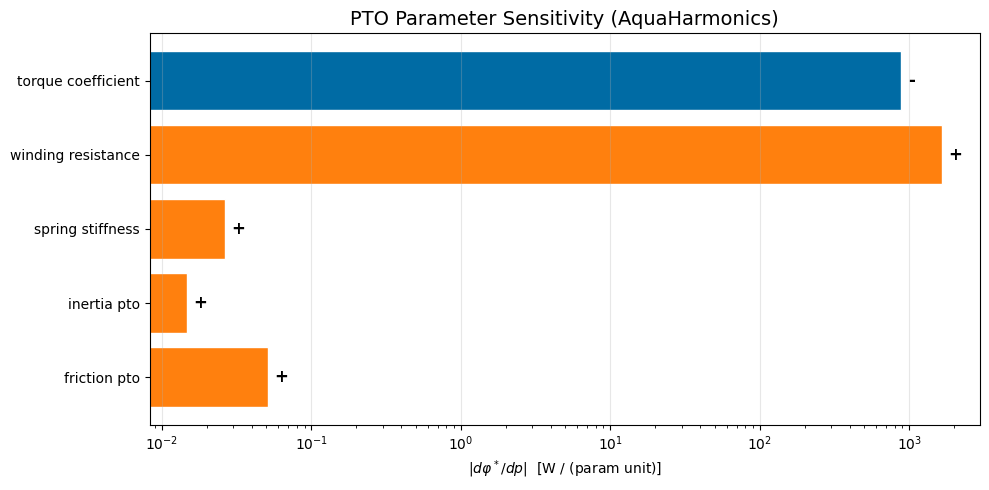

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

fields = PTOParams._fields
vals = [float(getattr(grad_pto, f)) for f in fields]
abs_vals = [abs(v) for v in vals]

colors_bar = [cc[0] if v < 0 else cc[1] for v in vals]
bars = ax.barh(range(len(fields)), abs_vals, color=colors_bar, edgecolor='white')

ax.set_yticks(range(len(fields)))
ax.set_yticklabels([f.replace('_', ' ') for f in fields])
ax.set_xlabel(r'$|d\varphi^*/dp|$  [W / (param unit)]')
ax.set_title('PTO Parameter Sensitivity (AquaHarmonics)', fontsize=14)
ax.set_xscale('log')

# Sign annotation
for i, (v, bar) in enumerate(zip(vals, bars)):
    sign = '+' if v > 0 else '-'
    ax.text(bar.get_width() * 1.1, bar.get_y() + bar.get_height()/2,
            f'{sign}', va='center', fontsize=12, fontweight='bold')

ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Analytical vs. FD comparison

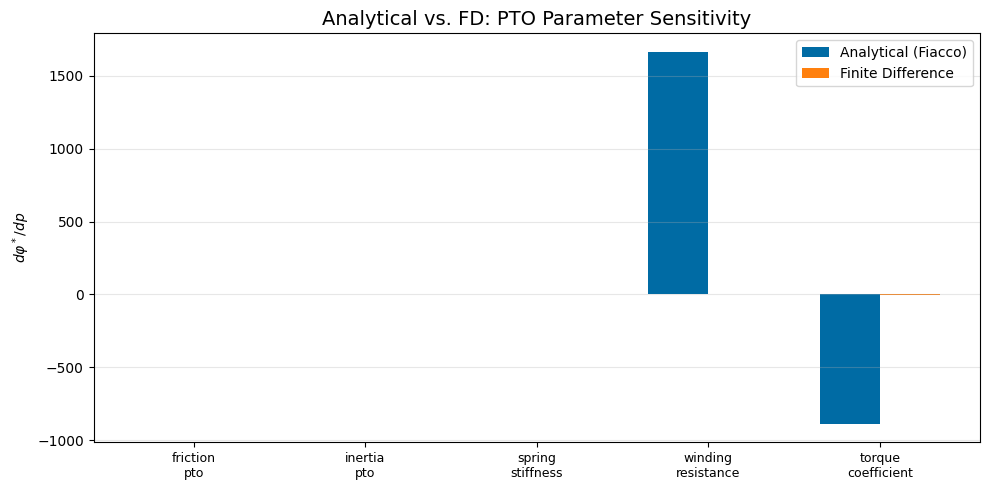

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

fields_with_fd = [f for f in PTOParams._fields if f in fd_results]
x_pos = np.arange(len(fields_with_fd))
width = 0.35

analytical_vals = [float(getattr(grad_pto, f)) for f in fields_with_fd]
fd_vals = [fd_results[f].fd for f in fields_with_fd]

ax.bar(x_pos - width/2, analytical_vals, width, label='Analytical (Fiacco)', color=cc[0])
ax.bar(x_pos + width/2, fd_vals, width, label='Finite Difference', color=cc[1])

ax.set_xticks(x_pos)
ax.set_xticklabels([f.replace('_', '\n') for f in fields_with_fd], fontsize=9)
ax.set_ylabel(r'$d\varphi^*/dp$')
ax.set_title('Analytical vs. FD: PTO Parameter Sensitivity', fontsize=14)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 9. Summary

This tutorial demonstrated **PTO parameter sensitivity** for the AquaHarmonics
WEC using the full Fiacco post-optimality formula.

### Method

`sensitivity()` computes:

$$\frac{d\varphi^*}{dp}
= \underbrace{\frac{\partial f}{\partial p}}_{\text{objective}}
+ \underbrace{\lambda^\top \frac{\partial r}{\partial p}}_{\text{dynamics}}
+ \underbrace{\sum_i \mu_i^\top \frac{\partial g_i}{\partial p}}_{\text{constraints}}$$

The user supplies:
- A **parameter pytree** (any JAX-compatible structure)
- **Parametric functions** for the residual, objective, and constraints

### Key features
- **General-purpose**: works with any parameter type, not just PTO or BEM
- **Full Fiacco formula**: includes inequality constraint multiplier terms
- **Auto-partition**: `additional_forces` auto-computed from `wec.forces` — no need to manually split forces
- **`make_joint_params`**: combine BEM and PTO parameters without defining ad-hoc namedtuples
- **`validate_sensitivity`**: run all FD checks (residual, objective, re-solve) in one call
- **Validated**: matches central finite differences through the full NLP
- **Composable**: can be combined with BEM sensitivity for joint gradients

### Applications
- Identify which PTO components most affect power output
- Guide drive train design decisions (gear ratios, generator sizing)
- Coupled shape + PTO optimization using joint gradients